In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [23]:
# Load your preprocessed dataset
df = pd.read_csv("processed_heart_disease.csv",)
df.drop(columns = ['Unnamed: 0'], inplace = True)
df.head()
df_b = df.copy()


In [24]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

import time
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split

In [25]:
# Assuming 'HeartDisease' is your target column
X = df.drop(columns=['result'])
y = df['result']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Since most features are binary/encoded categories:
nb = BernoulliNB()   # Best for binary features
# If you had continuous variables (like Age, BMI, etc.), use GaussianNB()
start_train = time.time()
nb.fit(X_train, y_train)
end_train = time.time()

# Predictions
start_pred = time.time()
y_pred = nb.predict(X_test)
y_proba = nb.predict(X_test)
end_pred = time.time()

# Evaluation
# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)

{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.16665244102478027,
                   'Training Time (s)': 0.268604040145874},
 'Extra': {'Confusion Matrix': [[40029, 5928], [2334, 2445]],
           'Overfitting Gap': 0.0010791154210029186},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.8371570482497634,
                            'Balanced Accuracy': 0.6913115826318772,
                            'F1-score': 0.3718065693430657,
                            'Precision': 0.2920100322465066,
                            'ROC-AUC': 0.6913115826318773,
                            'Recall': 0.5116133082234777}}


In [27]:
y_proba = nb.predict_proba(X_test)[:, 1]  # probability for class 1

# Try a custom threshold
threshold = 0.75   # instead of 0.5
y_pred = (y_proba >= threshold).astype(int)


# Evaluation
# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)


{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.16665244102478027,
                   'Training Time (s)': 0.268604040145874},
 'Extra': {'Confusion Matrix': [[41826, 4131], [2840, 1939]],
           'Overfitting Gap': -0.024366327656890507},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.8626024913276569,
                            'Balanced Accuracy': 0.6579225215590528,
                            'F1-score': 0.35745229975112913,
                            'Precision': 0.3194398682042834,
                            'ROC-AUC': 0.8200033194234356,
                            'Recall': 0.40573341703285204}}


In [28]:
y_proba = nb.predict_proba(X_test)[:, 1]  # probability for class 1

# Try a custom threshold
threshold = 0.9   # instead of 0.5
y_pred = (y_proba >= threshold).astype(int)


# Evaluation
# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)


{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.16665244102478027,
                   'Training Time (s)': 0.268604040145874},
 'Extra': {'Confusion Matrix': [[43178, 2779], [3281, 1498]],
           'Overfitting Gap': -0.042322019867549576},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.8805581835383159,
                            'Balanced Accuracy': 0.6264925641277079,
                            'F1-score': 0.3308303886925795,
                            'Precision': 0.3502454991816694,
                            'ROC-AUC': 0.8200033194234356,
                            'Recall': 0.3134546976354886}}


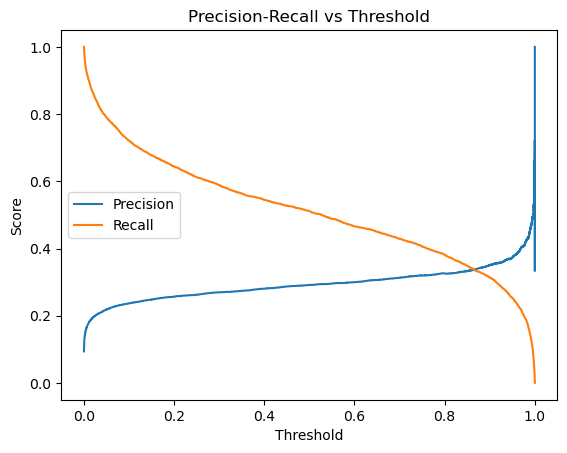

<Figure size 640x480 with 0 Axes>

In [29]:
prec, rec, thresh = precision_recall_curve(y_test, y_proba)

plt.plot(thresh, prec[:-1], label="Precision")
plt.plot(thresh, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()
plt.savefig('Precision-Recall vs Threshold (Whole Split).png')

In [36]:
temp = df[df['result'] == 1]
temp['result'].value_counts()

result
1    23893
Name: count, dtype: int64

In [37]:
temp = pd.concat([temp, df[df['result'] == 0].sample(23893)], ignore_index=True)
temp['result'].value_counts()

result
1    23893
0    23893
Name: count, dtype: int64

In [38]:
temp = temp.sample(23893*2)
temp.head()

,result,high_bp,high_chol,chol_check,smoker,stroke,diabetes,physical_activity,fruits,veggies,...,education:3,education:4,education:6,income:1,income:2,income:3,income:4,income:5,income:7,income:8
10282,1,1,1,1,0,0,2,1,0,1,...,0,0,0,1,0,0,0,0,0,0
15207,1,1,1,1,1,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
45064,0,1,1,1,0,0,0,1,1,1,...,0,0,1,0,0,0,0,0,1,0
42987,0,0,1,1,1,0,0,1,1,1,...,0,0,1,0,0,1,0,0,0,0
12115,1,1,0,1,0,1,0,1,1,1,...,0,0,1,0,0,0,0,0,0,1


In [44]:
# --- Load preprocessed dataset ---
df = temp

X_train = df.drop(columns=['result'])
y_train= df['result']

X_test = df_b.copy()
X_test.drop(columns = ['result'], inplace=True)
y_test = df_b['result'].copy()

# --- Training Time ---
start_train = time.time()
nb = BernoulliNB()
nb.fit(X_train, y_train)
end_train = time.time()

# --- Prediction Time ---
start_pred = time.time()
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)[:, 1]
end_pred = time.time()

# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)

{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.9440250396728516,
                   'Training Time (s)': 0.08342814445495605},
 'Extra': {'Confusion Matrix': [[173260, 56527], [6624, 17269]],
           'Overfitting Gap': -0.013626833097992841},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.7510603910438347,
                            'Balanced Accuracy': 0.7383833046352305,
                            'F1-score': 0.35355055328644985,
                            'Precision': 0.23400997344029487,
                            'ROC-AUC': 0.8197180099635819,
                            'Recall': 0.7227639894529778}}


In [20]:
# --- Prediction Time ---
start_pred = time.time()
y_pred = nb.predict(df.drop(columns=['result']))
y_proba = nb.predict_proba(df.drop(columns=['result']))[:, 1]
end_pred = time.time()

y_test = df['result']
# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)

{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.874880313873291,
                   'Training Time (s)': 0.07961273193359375},
 'Extra': {'Confusion Matrix': [[172958, 56829], [6566, 17327]],
           'Overfitting Gap': -0.010248177898038668},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.7500985493535163,
                            'Balanced Accuracy': 0.738939918947694,
                            'F1-score': 0.35343552713439197,
                            'Precision': 0.23365607637952424,
                            'ROC-AUC': 0.8201559761318367,
                            'Recall': 0.7251914786757627}}


In [46]:
y_proba = nb.predict_proba(X_test)[:, 1]  # probability for class 1

# Try a custom threshold
threshold = 0.9   # instead of 0.5
y_pred = (y_proba >= threshold).astype(int)


# Evaluation
# --- Predictive Performance ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# --- Computational ---
comp_metrics = {
    "Training Time (s)": end_train - start_train,
    "Prediction Time (s)": end_pred - start_pred,
    "Model Size (bytes)": nb.__sizeof__()   # rough estimate
}

# --- Interpretability ---
# Naive Bayes doesn't have rules like trees, but we can report feature usage
interpretability = {
    "# Features Used": X.shape[1],
    "Feature Log Prob Shape": nb.feature_log_prob_.shape
}

# --- Extra (Overfitting check) ---
train_pred = nb.predict(X_train)
overfit_gap = accuracy_score(y_train, train_pred) - accuracy_score(y_test, y_pred)

extra = {
    "Overfitting Gap": overfit_gap,
    "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
}

# --- Combine Everything ---
report = {
    "Predictive Performance": metrics,
    "Computational": comp_metrics,
    "Interpretability": interpretability,
    "Extra": extra
}

import pprint
pprint.pprint(report, width=100)


{'Computational': {'Model Size (bytes)': 32,
                   'Prediction Time (s)': 0.9440250396728516,
                   'Training Time (s)': 0.08342814445495605},
 'Extra': {'Confusion Matrix': [[199870, 29917], [11474, 12419]],
           'Overfitting Gap': -0.09940419039852899},
 'Interpretability': {'# Features Used': 52, 'Feature Log Prob Shape': (2, 52)},
 'Predictive Performance': {'Accuracy': 0.8368377483443709,
                            'Balanced Accuracy': 0.6947905910279297,
                            'F1-score': 0.37503208564224133,
                            'Precision': 0.2933437263794407,
                            'ROC-AUC': 0.8197180099635819,
                            'Recall': 0.5197756665132047}}


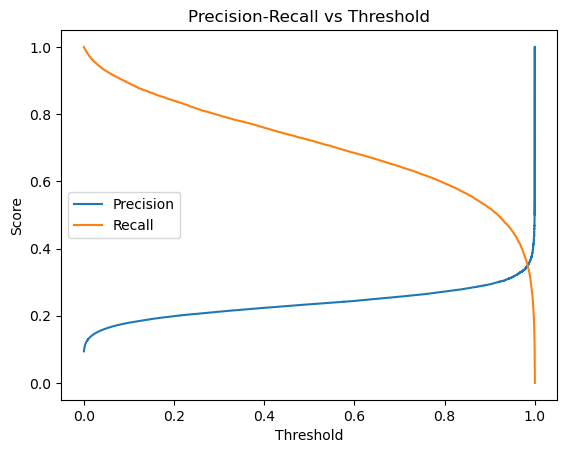

<Figure size 640x480 with 0 Axes>

In [47]:
prec, rec, thresh = precision_recall_curve(y_test, y_proba)

plt.plot(thresh, prec[:-1], label="Precision")
plt.plot(thresh, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()
plt.savefig('Precision-Recall vs Threshold (Balanced - Whole).png')